# Consistency between Rare Cell Types and Topics
This tutorial evaluates how well scE2TM captures rare cell populations by analyzing the consistency between rare cell types and learned topics.

In [41]:
"""
Cell type clustering evaluation using scE2TM embeddings
This script loads pre-trained topic distributions and evaluates clustering performance
"""

import scanpy as sc
import pandas as pd
import numpy as np 
import os
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, silhouette_score, davies_bouldin_score

# ============================================================================
# Configuration - Get current directory and set dataset name
# ============================================================================

# Get the current directory - works in both Jupyter notebook and Python scripts
try:
    # This works when running as a script
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # This works in Jupyter notebook
    current_dir = os.getcwd()

print(f"Current working directory: {current_dir}")

# Define dataset name (case-sensitive, matches folder name)
dataset_name = 'Wang'  # Base name for the data files
print(f"Processing dataset: {dataset_name}")

# Define data paths relative to the script location
# Script is in tutorial/ directory, so we go up one level to project root
# Project structure:
# scE2TM_github/
# ├── tutorial/                    # This script is here
# │   └── this_script.py
# ├── data/                        # Input data directory
# │   └── {dataset_name}_cell_anno.csv
# └── output/                      # Output directory from training
#     └── {dataset_name}/
#         └── {dataset_name}_topic_distribution.csv

embedding_path = os.path.join(current_dir, '..', 'output', dataset_name, f'{dataset_name}_topic_distribution.csv')
label_path = os.path.join(current_dir, '..', 'data', f'{dataset_name}_cell_anno.csv')

print(f"Loading embeddings from: {embedding_path}")
print(f"Loading labels from: {label_path}")

# ============================================================================
# Check if files exist
# ============================================================================

if not os.path.exists(embedding_path):
    print(f"ERROR: Embedding file not found at {embedding_path}")
    print("Please make sure the embedding file is in the correct location.")
    print("Expected structure:")
    print("  scE2TM_github/")
    print("  ├── tutorial/")
    print("  │   └── this_script.py")
    print("  └── output/")
    print(f"      └── {dataset_name}/")
    print(f"          └── {dataset_name}_topic_distribution.csv")
    import sys
    sys.exit(1)

if not os.path.exists(label_path):
    print(f"ERROR: Label file not found at {label_path}")
    print("Please make sure the label file is in the correct location.")
    import sys
    sys.exit(1)

# ============================================================================
# Load scE2TM embeddings
# ============================================================================

# Load topic distribution file (rows = cells, columns = topic dimensions)
# The file is in CSV format with cells as rows and embedding dimensions as columns
embedding_df = pd.read_csv(embedding_path, sep=',', index_col=0)
print(f"Embedding shape: {embedding_df.shape}")

# Create AnnData object with embeddings in .X
# AnnData is the standard data structure for single-cell analysis in scanpy
adata = sc.AnnData(embedding_df.values)

# Store embeddings in obsm for consistency with scanpy workflows
adata.obsm["X_scE2TM"] = embedding_df.values

# Preserve cell names
adata.obs_names = embedding_df.index

# ============================================================================
# Load cell type annotations
# ============================================================================

# Read ground truth cell type labels (rows = cells, first column = cell types)
# The label file should be in CSV format with cell names as index
label = pd.read_csv(label_path, sep=',', index_col=0)

# Extract the correct column name (dataset name + "@colData$cell_type1")
# Following the format from the other tutorial
label_column = f"{dataset_name.lower()}@colData$cell_type1"

# Add cell type annotations to AnnData object
adata.obs['cell_type'] = list(label[label_column])

print(f"Number of cells: {len(adata.obs['cell_type'])}")
print(f"Number of topics: {adata.n_vars}")
print(f"Unique cell types: {adata.obs['cell_type'].nunique()}")
print(f"Cell type distribution:\n{adata.obs['cell_type'].value_counts()}")

Current working directory: /mnt/rao/home/chenhg/Methods/ECRTM-Singlecell/scE2TM_github/tutorial
Processing dataset: Wang
Loading embeddings from: /mnt/rao/home/chenhg/Methods/ECRTM-Singlecell/scE2TM_github/tutorial/../output/Wang/Wang_topic_distribution.csv
Loading labels from: /mnt/rao/home/chenhg/Methods/ECRTM-Singlecell/scE2TM_github/tutorial/../data/Wang_cell_anno.csv
Embedding shape: (457, 100)
Number of cells: 457
Number of topics: 100
Unique cell types: 7
Cell type distribution:
cell_type
alpha         190
beta          111
ductal         96
mesenchyme     27
gamma          18
delta           9
acinar          6
Name: count, dtype: int64


/mnt/rao/home/chenhg/.local/lib/python3.8/site-packages/anndata/_core/anndata.py:864: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer

  names = self._prep_dim_index(names, "obs")


In [42]:
"""
Topic-Cell Type Matching Evaluation
This script evaluates how well each topic captures specific cell types by finding the best-matched topic for each cell type.

The analysis identifies which topic is most representative of each cell type and calculates classification metrics
to quantify the alignment between topics and ground truth labels.
"""

import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score


def evaluate_topic_capture(adata, type_key="cell_type", topic_key="topic_ass"):
    """
    Evaluate topic-cell type associations by finding the best-matching topic for each cell type.
    
    For each cell type, this function:
        1) Identifies the topic that contains the highest number of cells from that type
        2) Calculates classification metrics treating that topic as the "predictor" for the cell type
    
    Parameters:
    -----------
    adata : AnnData
        AnnData object containing cell type annotations and topic assignments
    type_key : str, default="cell_type"
        Column name in adata.obs containing ground truth cell type labels
    topic_key : str, default="topic_ass"
        Column name in adata.obs containing assigned topic IDs for each cell
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with evaluation metrics for each cell type:
        - cell_type: Name of the cell type
        - best_topic: Topic ID that best represents this cell type
        - n_cells: Number of cells in this cell type
        - recall: Recall = TP/(TP+FN) - proportion of cells from this type assigned to best_topic
        - precision: Precision = TP/(TP+FP) - proportion of cells in best_topic that belong to this type
        - f1: F1 score = 2 * (precision * recall) / (precision + recall)
        - purity: Proportion of cells in best_topic that belong to this type (same as precision in this context)
    """
    
    # Create a copy of relevant columns for analysis
    df = adata.obs[[type_key, topic_key]].copy()
    
    # Convert to string to ensure consistent handling
    df[type_key] = df[type_key].astype(str)
    df[topic_key] = df[topic_key].astype(str)
    
    results = []
    
    # Get all unique cell types
    cell_types = df[type_key].unique()
    
    for ct in cell_types:
        # Subset cells belonging to the current cell type
        type_cells = df[df[type_key] == ct]
        
        # Count how many cells from this type are assigned to each topic
        topic_counts = type_cells[topic_key].value_counts()
        
        # Find the topic that contains the most cells from this type
        # This topic is considered the "best representative" for this cell type
        best_topic = topic_counts.idxmax()
        
        # Create binary labels:
        # y_true: whether a cell belongs to the current cell type (1) or not (0)
        # y_pred: whether a cell is assigned to the best_topic (1) or not (0)
        y_true = (df[type_key] == ct).astype(int)
        y_pred = (df[topic_key] == best_topic).astype(int)
        
        # Calculate classification metrics
        recall = recall_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        
        # Calculate purity: proportion of cells in best_topic that belong to this cell type
        # This measures how "pure" the topic is for this cell type
        topic_cells = df[df[topic_key] == best_topic]
        purity = (topic_cells[type_key] == ct).mean()
        
        # Store results
        results.append({
            "cell_type": ct,
            "best_topic": best_topic,
            "n_cells": int((df[type_key] == ct).sum()),
            "recall": recall,
            "precision": precision,
            "f1": f1,
            "purity": purity
        })
    
    # Sort by F1 score (higher = better topic-cell type alignment)
    result_df = pd.DataFrame(results).sort_values("f1", ascending=False)
    
    return result_df


# ============================================================================
# Apply the evaluation to the AnnData object
# ============================================================================

# Topic assignments: For each cell, find the topic with the highest probability
# np.argmax returns the index of the maximum value along axis=1 (rows)
# This gives us the most likely topic for each cell
topic_assignments = np.asarray(np.argmax(adata.X, axis=1)).flatten()

# Store topic assignments in the AnnData object for later use
adata.obs["topic_ass"] = topic_assignments

# Run evaluation to find best-matching topic for each cell type
result_df = evaluate_topic_capture(adata)

# Display results
result_df

,cell_type,best_topic,n_cells,recall,precision,f1,purity
4,gamma,51,18,0.777778,0.823529,0.800000,0.823529
6,mesenchyme,36,27,0.518519,0.875000,0.651163,0.875000
1,ductal,27,96,0.354167,0.971429,0.519084,0.971429
5,acinar,82,6,0.500000,0.500000,0.500000,0.500000
3,beta,70,111,0.171171,0.950000,0.290076,0.950000
0,alpha,66,190,0.105263,1.000000,0.190476,1.000000
2,delta,86,9,0.222222,0.117647,0.153846,0.117647



Rare Cell Type Analysis
Smallest (rarest) cell type: acinar
Number of cells: 6
Best-matching topic: 82
F1 Score: 0.5000

Visualizing acinar...



/mnt/rao/home/chenhg/anaconda3/envs/scE2TM/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not f

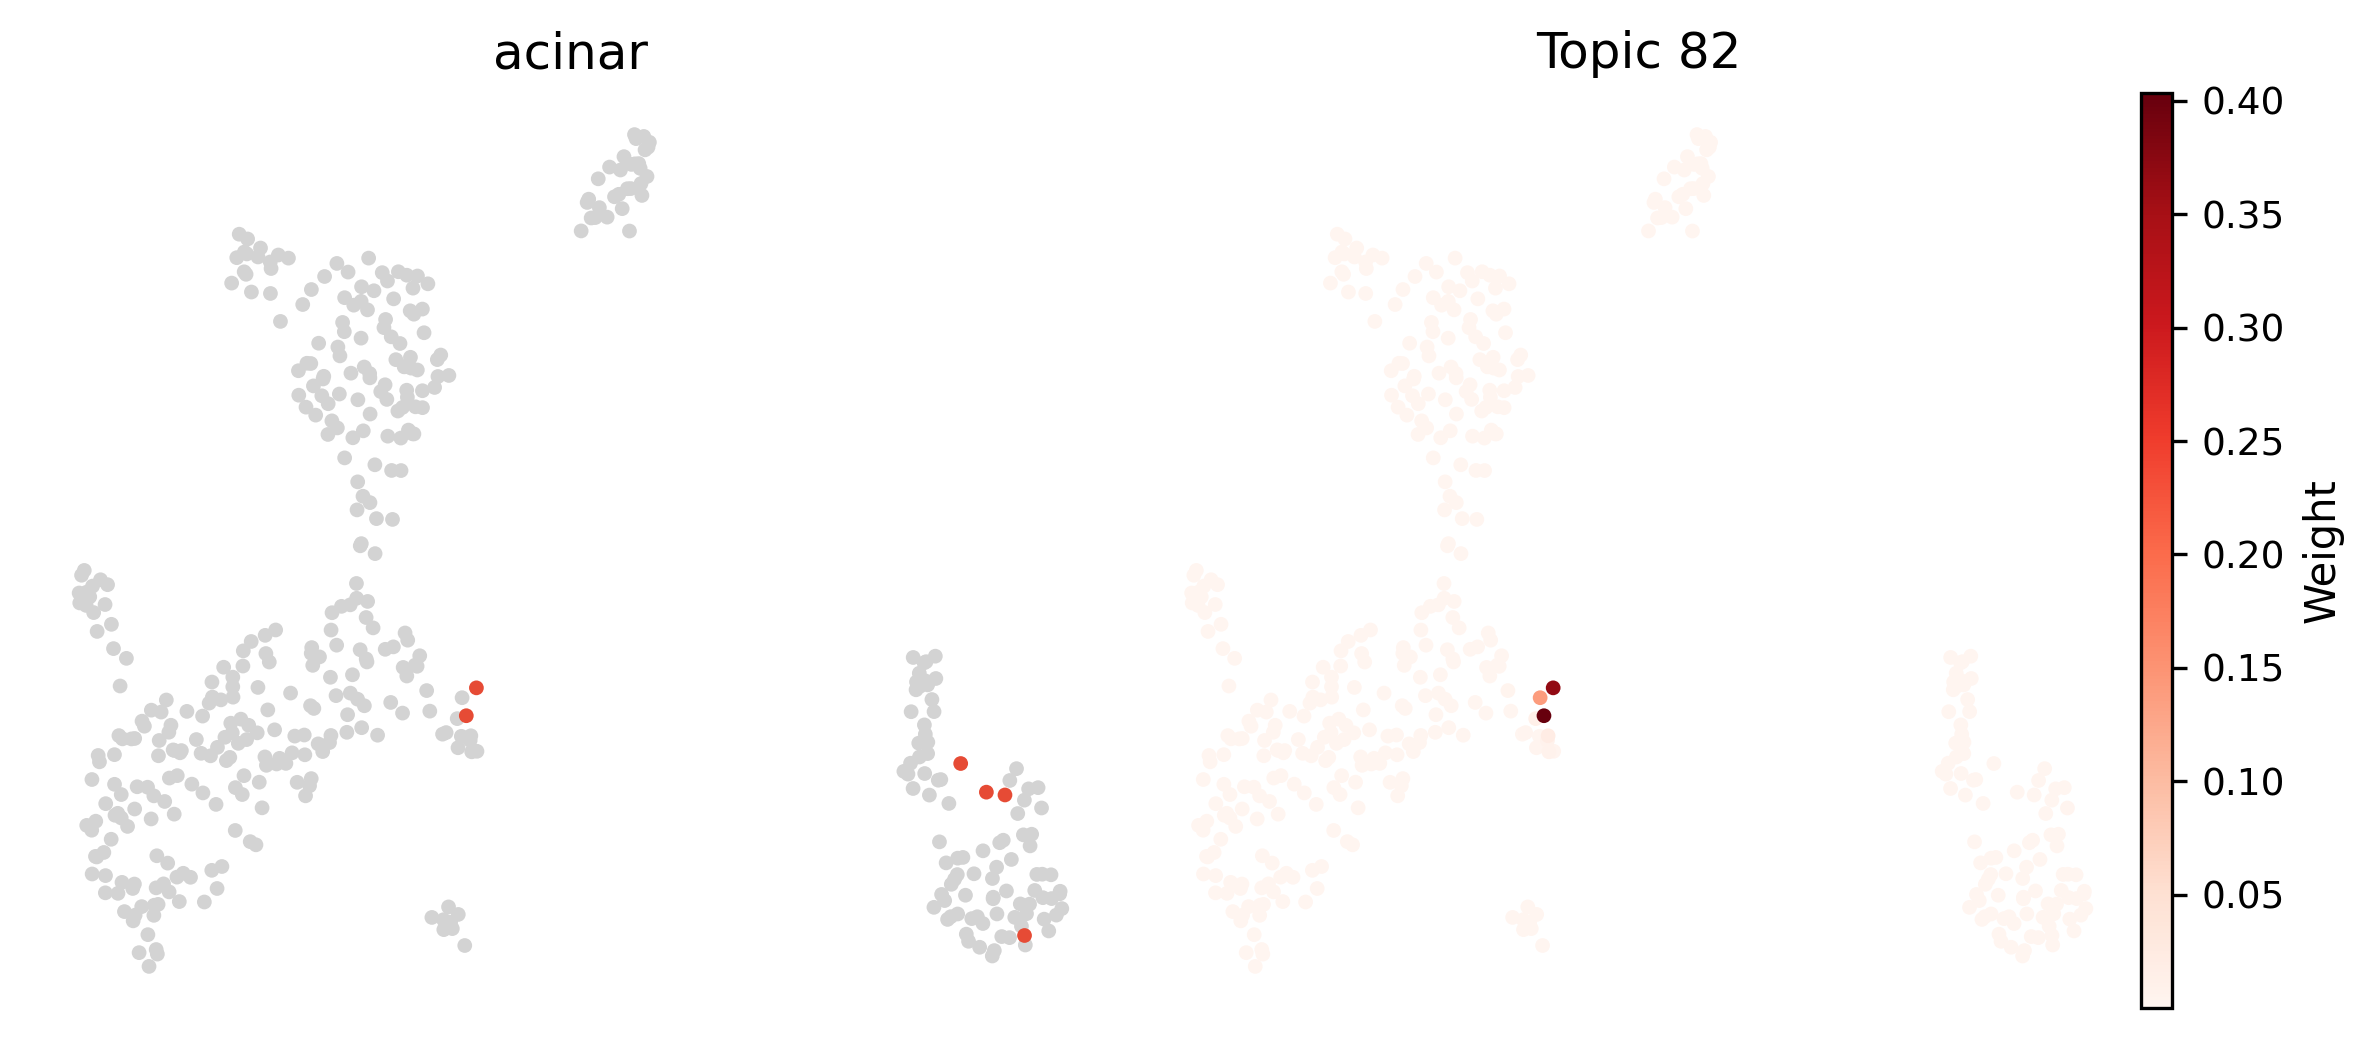


✅ Visualization complete for rare cell type: acinar


In [43]:
# ============================================================================
# UMAP Visualization of Rare Cell Types
# This section visualizes the smallest (rarest) cell type in the dataset
# and its corresponding best-matched topic from scE2TM
# ============================================================================

# Compute UMAP for dimensionality reduction using the original embeddings
# Step 1: PCA for initial dimensionality reduction
sc.pp.pca(adata)

# Step 2: Construct neighborhood graph (required for UMAP)
sc.pp.neighbors(adata, use_rep='X')

# Step 3: Compute UMAP coordinates
sc.tl.umap(adata)

# ============================================================================
# Identify the smallest (rarest) cell type
# ============================================================================

# Sort cell types by number of cells (ascending) to find the rarest ones
result_df_sorted_by_cells = result_df.sort_values('n_cells').reset_index(drop=True)

# Get the smallest cell type (rarest population)
smallest_cell_type = result_df_sorted_by_cells.iloc[0]['cell_type']

# Get its best-matching topic (the topic that contains the most cells from this type)
smallest_topic = int(result_df_sorted_by_cells.iloc[0]['best_topic'])

# Print information about the rare cell type
print(f"\n{'='*60}")
print(f"Rare Cell Type Analysis")
print(f"{'='*60}")
print(f"Smallest (rarest) cell type: {smallest_cell_type}")
print(f"Number of cells: {result_df_sorted_by_cells.iloc[0]['n_cells']}")
print(f"Best-matching topic: {smallest_topic}")
print(f"F1 Score: {result_df_sorted_by_cells.iloc[0]['f1']:.4f}")
print(f"{'='*60}\n")

# ============================================================================
# Helper function: Softmax normalization for topic weights
# ============================================================================

def get_softmax_weights(topic_idx):
    """
    Apply softmax normalization to topic weights across all cells.
    
    Softmax converts raw topic weights to a probability distribution,
    ensuring weights sum to 1 across all cells. This makes the weights
    more interpretable as "cell-wise importance" for the given topic.
    
    Parameters:
    -----------
    topic_idx : int
        Index of the topic to normalize
        
    Returns:
    --------
    np.ndarray
        Softmax-normalized weights for the specified topic (sum = 1)
    """
    # Extract raw weights for the specified topic across all cells
    topic_weights = raw_embedding[:, topic_idx].copy()
    
    # Convert to tensor for softmax operation
    weights_tensor = torch.from_numpy(topic_weights).float()
    
    # Apply softmax along the cell dimension (dim=0)
    # This ensures weights sum to 1 across all cells
    softmax_weights = F.softmax(weights_tensor, dim=0).numpy()
    
    return softmax_weights


# ============================================================================
# Visualize rare cell type and its best-matched topic
# ============================================================================

print(f"Visualizing {smallest_cell_type}...\n")

# Create figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

# ----- Left subplot: Ground truth cell type -----
# Highlight the rare cell type in UMAP space
sc.pl.umap(
    adata,
    color='cell_type',
    groups=[smallest_cell_type],          # Only highlight the rare cell type
    palette=['#E64B35'],                  # Red color for highlighting
    ax=axes[0],
    title=smallest_cell_type,
    frameon=False,
    show=False,
    size=50,                               # Point size for better visibility
    legend_loc='none'                      # Hide legend for cleaner look
)

# ----- Right subplot: Topic weights for the best-matching topic -----
# Calculate softmax-normalized weights for the best topic
softmax_weights = get_softmax_weights(smallest_topic)

# Store weights in AnnData for visualization
weight_col = f'topic_{smallest_topic}_softmax'
adata.obs[weight_col] = softmax_weights

# Visualize topic weights on UMAP (darker red = higher weight)
sc.pl.umap(
    adata,
    color=weight_col,
    ax=axes[1],
    title=f'Topic {smallest_topic}',
    frameon=False,
    show=False,
    size=50,                               # Point size for better visibility
    cmap='Reds',                           # Red colormap for weight intensity
    colorbar_loc='right'
)

# ----- Formatting adjustments -----
# Set title font sizes
axes[0].set_title(smallest_cell_type, fontsize=12)
axes[1].set_title(f'Topic {smallest_topic}', fontsize=12)

# Adjust colorbar appearance
cbar = axes[1].collections[-1].colorbar
cbar.ax.tick_params(labelsize=9)
cbar.set_label('Weight', fontsize=10)

# Adjust layout for better spacing
plt.tight_layout()

# Display the figure
plt.show()

# Close the figure to free memory (important when running in loops)
plt.close()

print(f"\n✅ Visualization complete for rare cell type: {smallest_cell_type}")

Loaded topic-gene matrix shape: (5000, 100)


2026-03-25 10:08:35,187 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-25 10:08:35,189 [INFO] Parsing data files for GSEA.............................
2026-03-25 10:08:35,193 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=3
2026-03-25 10:08:35,195 [INFO] 0001 gene_sets used for further statistical testing.....
2026-03-25 10:08:35,196 [INFO] Start to run GSEA...Might take a while..................


Assigned 5000 gene names

Topic 82 weights statistics:
  Number of genes: 5000
  Weight range: [0.0006, 0.0891]
  Top 10 genes by weight:
GCG         0.022855
MALAT1      0.001485
REG1A       0.059198
PPY         0.027403
SST         0.030381
TTR         0.015799
PRSS1       0.062277
INS         0.016169
SERPINA1    0.016985
REG1B       0.047157
Name: 82, dtype: float64

Prepared ranking DataFrame with 5000 genes


2026-03-25 10:08:35,786 [INFO] Congratulations. GSEApy runs successfully................




GSEA Analysis Results
      Name               Term        ES       NES NOM p-val FDR q-val  \
0  prerank  Rare_Cell_Markers  0.790707  2.288719       0.0       0.0   

  FWER p-val Tag % Gene %                         Lead_genes  
0        0.0   6/8  4.00%  CPA1;CTRC;PRSS1;CTRB1;REG3A;CTRB2  

Found 1 enriched gene sets

Generating enrichment plot for: Rare_Cell_Markers


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because


Enrichment Summary
Gene Set: Rare_Cell_Markers
Enrichment Score (ES): 0.7907
Normalized Enrichment Score (NES): 2.2887
Nominal P-value: 0.0000
FDR q-value: 0.0000
FWER p-value: 0.0000
Tag %: 75.0% (6/8 markers found before peak)
Gene %: 4.0%
Leading Edge Genes: CPA1;CTRC;PRSS1;CTRB1;REG3A;CTRB2

Interpretation
✅ Significant positive enrichment detected (FDR < 0.05)
   The rare cell type markers are significantly enriched in this topic
   This indicates that the topic captures the biological signature
   of the rare cell population.

   Key marker genes enriched: CPA1;CTRC;PRSS1;CTRB1;REG3A;CTRB2



findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

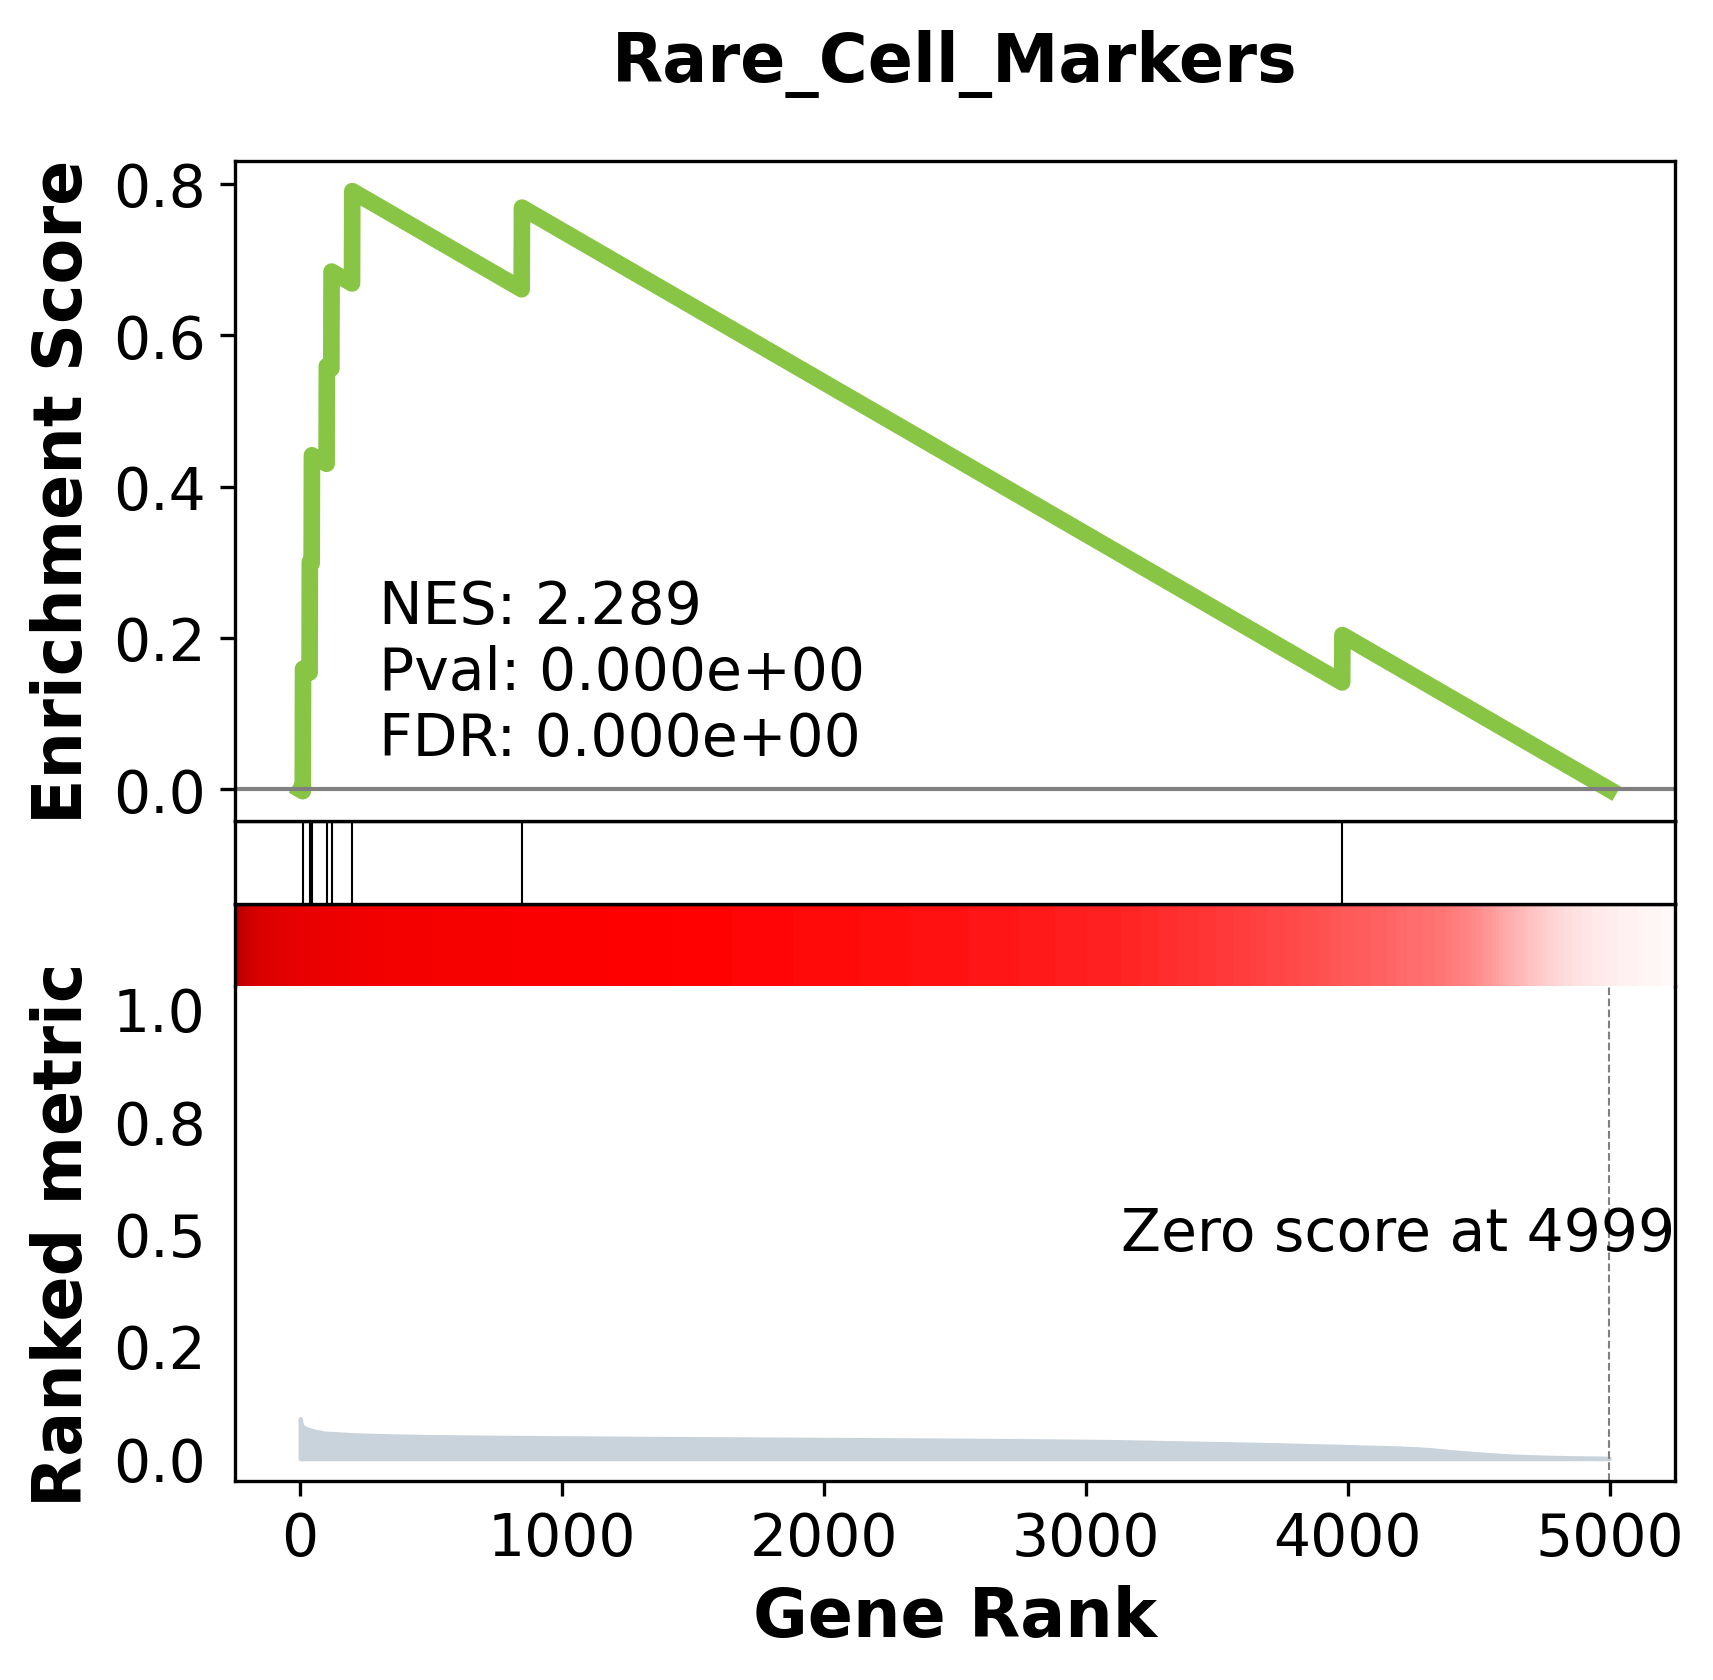

In [44]:
"""
GSEA Analysis for Rare Cell Type Markers
This script performs Gene Set Enrichment Analysis (GSEA) to evaluate whether the
best-matching topic for the rarest cell type is enriched for known marker genes.
"""

import gseapy as gp
from gseapy import prerank
import pandas as pd
import numpy as np
import os

# ============================================================================
# Configuration
# ============================================================================

# Define marker genes for the rare cell type (e.g., acinar cells in pancreas)
# These are known marker genes that characterize the cell population
rare_cell_markers = ["BMI1", "PRSS1", "CTRC", "CPA1", "CTRB1", "REG1B", 
                     "CTRB2", "AMY2B", "REG3A", "TRYPSIN"]

# Get the current script directory for relative path handling
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()

# Define data paths relative to project root
# Note: This script is in the tutorial/ directory, so go up one level
project_root = os.path.join(current_dir, '..')

# Path to topic-gene weights matrix
topic_gene_path = os.path.join(project_root, 'output', 'Wang', 'Wang_tg.csv')

# Path to gene names (reference)
gene_names_path = os.path.join(project_root, 'data', 'Wang_HIGHPRE.csv')

# ============================================================================
# Load Data
# ============================================================================

# Load topic-gene weight matrix
# This file contains topic weights for each gene (rows = topics, columns = genes)
topic_gene_df = pd.read_csv(topic_gene_path, sep=',', index_col=0).T
print(f"Loaded topic-gene matrix shape: {topic_gene_df.shape}")

# Load gene names reference
# This file contains the complete list of gene names in the correct order
gene_names_df = pd.read_csv(gene_names_path, sep=',', index_col=0)
gene_names = gene_names_df.columns

# Assign proper gene names to the topic-gene matrix
topic_gene_df.index = gene_names
print(f"Assigned {len(gene_names)} gene names")

# ============================================================================
# Extract Topic Weights for the Best-Matching Topic
# ============================================================================

# Define the topic index that best matches the rare cell type
# This should be determined from previous analysis (e.g., from result_df)
# For this example, we're using topic 82 (0-based indexing)
topic_idx = 82  # Topic that best represents the rare cell type

# Extract weights for the specified topic
# Note: .iloc[:, topic_idx] selects the column (topic) by index
topic_weights = topic_gene_df.iloc[:, topic_idx].copy()

print(f"\nTopic {topic_idx} weights statistics:")
print(f"  Number of genes: {len(topic_weights)}")
print(f"  Weight range: [{topic_weights.min():.4f}, {topic_weights.max():.4f}]")
print(f"  Top 10 genes by weight:")
print(topic_weights.head(10))

# ============================================================================
# Prepare Data for GSEA Prerank Analysis
# ============================================================================

# Sort genes by weight in descending order (highest weight = most important)
# This creates a ranked gene list required for GSEA prerank
ranked_genes = topic_weights.sort_values(ascending=False)

# Create DataFrame in the format expected by gseapy.prerank
# The function expects a DataFrame with 'gene' and 'score' columns
ranking_df = pd.DataFrame({
    'gene': ranked_genes.index,
    'score': ranked_genes.values
})

print(f"\nPrepared ranking DataFrame with {len(ranking_df)} genes")

# ============================================================================
# Perform GSEA Prerank Analysis
# ============================================================================

# Define custom gene set (marker genes for the rare cell type)
custom_gene_sets = {'Rare_Cell_Markers': rare_cell_markers}

# Run GSEA prerank
# This tests whether the marker genes are enriched at the top of the ranked list
gsea_results = prerank(
    rnk=ranking_df,                          # Ranked gene list (sorted by weight)
    gene_sets=custom_gene_sets,              # Custom gene set for testing
    min_size=3,                              # Minimum gene set size to consider
    max_size=500,                            # Maximum gene set size to consider
    permutation_num=1000,                    # Number of permutations for significance testing
    verbose=True,                            # Print progress information
    ascending=False,                         # False = highest scores first
)

# ============================================================================
# View and Visualize Results
# ============================================================================

# Display the GSEA results table
print("\n" + "="*60)
print("GSEA Analysis Results")
print("="*60)
print(gsea_results.res2d)

# Check if any gene sets were significantly enriched
if len(gsea_results.res2d) > 0:
    print(f"\nFound {len(gsea_results.res2d)} enriched gene sets")
    
    # Visualize the enrichment plot for the first (and likely only) gene set
    from gseapy import gseaplot
    
    # Get the term name from results
    term_name = gsea_results.res2d.Term.iloc[0]
    
    print(f"\nGenerating enrichment plot for: {term_name}")
    
    # Plot GSEA enrichment curve
    # This shows the running enrichment score as we move down the ranked gene list
    gseaplot(
        rank_metric=gsea_results.ranking,      # Ranked metric values
        term=term_name,                         # Name of the gene set to plot
        **gsea_results.results[term_name]       # Results dictionary for this term
    )
    
    # Extract and display key metrics
    # Convert values to appropriate types (handling potential string values)
    es = float(gsea_results.res2d['ES'].iloc[0])           # Enrichment Score
    nes = float(gsea_results.res2d['NES'].iloc[0])         # Normalized Enrichment Score
    p_val = float(gsea_results.res2d['NOM p-val'].iloc[0]) # Nominal P-value
    fdr = float(gsea_results.res2d['FDR q-val'].iloc[0])   # False Discovery Rate
    fwer = float(gsea_results.res2d['FWER p-val'].iloc[0]) # Family-wise error rate
    
    # Handle Tag % and Gene % - they might be strings like "6/8" or percentages
    tag_percent_raw = gsea_results.res2d['Tag %'].iloc[0]
    gene_percent_raw = gsea_results.res2d['Gene %'].iloc[0]
    
    # Convert Tag % to numeric if it's in format like "6/8" or "75.0%"
    if isinstance(tag_percent_raw, str):
        if '/' in tag_percent_raw:
            # Format like "6/8" - convert to percentage
            numerator, denominator = tag_percent_raw.split('/')
            tag_percent = float(numerator) / float(denominator) * 100
            markers_found = int(numerator)
            markers_total = int(denominator)
        elif '%' in tag_percent_raw:
            # Format like "75.0%" - remove % sign and convert
            tag_percent = float(tag_percent_raw.replace('%', ''))
            markers_found = int(round(tag_percent * len(rare_cell_markers) / 100))
            markers_total = len(rare_cell_markers)
        else:
            tag_percent = float(tag_percent_raw)
            markers_found = int(round(tag_percent * len(rare_cell_markers) / 100))
            markers_total = len(rare_cell_markers)
    else:
        tag_percent = float(tag_percent_raw)
        markers_found = int(round(tag_percent * len(rare_cell_markers) / 100))
        markers_total = len(rare_cell_markers)
    
    # Convert Gene % to numeric
    if isinstance(gene_percent_raw, str):
        if '%' in gene_percent_raw:
            gene_percent = float(gene_percent_raw.replace('%', ''))
        else:
            gene_percent = float(gene_percent_raw)
    else:
        gene_percent = float(gene_percent_raw)
    
    leading_genes = str(gsea_results.res2d['Lead_genes'].iloc[0])
    
    print("\n" + "="*60)
    print("Enrichment Summary")
    print("="*60)
    print(f"Gene Set: {term_name}")
    print(f"Enrichment Score (ES): {es:.4f}")
    print(f"Normalized Enrichment Score (NES): {nes:.4f}")
    print(f"Nominal P-value: {p_val:.4f}")
    print(f"FDR q-value: {fdr:.4f}")
    print(f"FWER p-value: {fwer:.4f}")
    print(f"Tag %: {tag_percent:.1f}% ({markers_found}/{markers_total} markers found before peak)")
    print(f"Gene %: {gene_percent:.1f}%")
    print(f"Leading Edge Genes: {leading_genes}")
    
    # Interpretation of results
    print("\n" + "="*60)
    print("Interpretation")
    print("="*60)
    
    if fdr < 0.05 and nes > 0:
        print("✅ Significant positive enrichment detected (FDR < 0.05)")
        print("   The rare cell type markers are significantly enriched in this topic")
        print("   This indicates that the topic captures the biological signature")
        print("   of the rare cell population.")
        
        if len(leading_genes.split(';')) >= 3:
            print(f"\n   Key marker genes enriched: {leading_genes}")
    elif nes < 0:
        print("⚠️  Negative enrichment detected")
        print("   The markers are depleted in this topic (enriched at the bottom of the list)")
    else:
        print("⚠️  No significant enrichment detected (FDR >= 0.05)")
        print("   The rare cell type markers may not be well-represented in this topic")
else:
    print("\n⚠️  No enriched gene sets found")
    
print("\n" + "="*60)